# PrototypeNine-v1.5 — Generation + Stage-1 Heuristic QA + Masks/Metadata

This notebook extends PrototypeNine-v1.4 by keeping the existing generation workflow, strengthening the inline heuristic QA, and saving **per-object masks** plus **per-image metadata** for a later VLM-based QA stage.

In [4]:
# -----------------------
# Section 0 - Imports + config
# -----------------------
import os, random, shutil, json
from pathlib import Path

import torch
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

from diffusers import StableDiffusionXLInpaintPipeline

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# --------- PATHS (relative) ----------
BASE_DIR = Path.cwd()

BACKGROUND_DIR = BASE_DIR / "Real_Background_Images"
REF_ROOT       = BASE_DIR / "IP_ADAPTER_REFERENCES"

ROPE_REF_DIR    = REF_ROOT / "rope"
PLASTIC_REF_DIR = REF_ROOT / "plastic_bottles"
TIRES_REF_DIR   = REF_ROOT / "tires"

EXPERIMENT_NAME = "PrototypeNine_v1_5"

output_root = BASE_DIR / "output" / EXPERIMENT_NAME
output_image_dir    = output_root / "images"
output_label_dir    = output_root / "labels_yolo"
output_mask_dir     = output_root / "masks"
output_metadata_dir = output_root / "metadata"
qa_output_dir       = output_root / "qa"

for _d in [output_root, output_image_dir, output_label_dir, output_mask_dir, output_metadata_dir, qa_output_dir]:
    _d.mkdir(parents=True, exist_ok=True)

manifest_csv_path   = output_metadata_dir / "manifest.csv"
manifest_jsonl_path = output_metadata_dir / "manifest.jsonl"

# ---------- DATASET SETTINGS ----------
TARGET_SIZE = (640, 640)  # (W, H) keep same behaviour as PrototypeSix
W, H = TARGET_SIZE

# Context patch settings for aspect-ratio preserving local inpainting
CONTEXT_MIN_PAD = 20
CONTEXT_PAD_FRACTION = 0.30

# 30 backgrounds * 5 variants = 150 images total (no rotation)
MAX_BACKGROUNDS = 30
VARIANTS_PER_BG = 5

# Total objects per generated image
TOTAL_INSERTS_MIN, TOTAL_INSERTS_MAX = 8, 13

# Rope inserts per image
ROPE_INSERTS_MIN, ROPE_INSERTS_MAX = 3, 5

# Multi-class YOLO ids
CLASS_MAP = {
    "rope": 0,
    "plastic_bottles": 1,
    "tires": 2
}
CLASSES = ["rope", "plastic_bottles", "tires"]

# Optional: show each result inline (slow)
SHOW_EACH_RESULT = False

# ---------- PIPELINE / IP-ADAPTER ----------
MODEL_ID = "diffusers/stable-diffusion-xl-1.0-inpainting-0.1"

IP_ADAPTER_REPO = "h94/IP-Adapter"
IP_ADAPTER_SUBFOLDER = "sdxl_models"
IP_ADAPTER_WEIGHT_NAME = "ip-adapter-plus_sdxl_vit-h.safetensors"
IP_ADAPTER_SCALE = 0.7

# ---------- GENERATION SETTINGS ----------
NUM_INFERENCE_STEPS = 40
GUIDANCE_SCALE = 6.5

ROPE_PROMPTS = [
    "a faded rope lying on sand, top-down drone view, photo-realistic",
    "a weathered rope strand lying on the shoreline, top-down drone view, photo-realistic",
    "a dirty rope loosely curved on sand, top-down drone view, photo-realistic",
    "a tangled rope on the shoreline, top-down drone view, photo-realistic",
    "a coiled rope on sand, top-down drone view, photo-realistic",
    "a partially coiled rope with loose ends, top-down drone view, photo-realistic",
]

PLASTIC_PROMPTS = [
    "a discarded plastic bottle lying on sand, top-down drone view, photo-realistic",
    "a plastic jug lying on the shoreline, top-down drone view, photo-realistic",
    "a crushed plastic bottle on sand, top-down drone view, photo-realistic",
]

TIRES_PROMPTS = [
    "a discarded tire lying on sand, top-down drone view, photo-realistic",
    "a dirty tire on the shoreline, top-down drone view, photo-realistic",
]

OTHER_PROMPTS = ["a small piece of debris lying on sand, top-down drone view, photo-realistic"]  # (unused in PrototypeNine-v2)

NEG_PROMPT = "cartoon, illustration, text, logo, watermark, unrealistic, blurry, nude, nsfw"

# Placement / overlap control (same pattern as PrototypeSix)
MAX_PLACEMENT_TRIES = 140
MAX_IOU = 0.10
PADDING = 5



# ---------- Class-specific mask sizing (edit these easily) ----------
MASK_SPECS = {
    # max_bbox roughly controls how big the *mask* can be in pixels (on the 640x640 image)
    "rope": {"edge_margin": 120, "max_bbox": 210},
    "plastic_bottles": {"edge_margin": 90, "max_bbox": 260},
    "tires": {"edge_margin": 135, "max_bbox": 320},
}

# Per-class crop padding around the contour bbox (pixels)
PADDING_BY_CLASS = {
    "rope": 5,
    "plastic_bottles": 8,
    "tires": 14,
}

# Per-class keep-out margin (pixels) to stop masks/bboxes overlapping
KEEP_OUT_BY_CLASS = {
    "rope": 10,
    "plastic_bottles": 16,
    "tires": 30,
}

# Mask edge blur (0 = hard edge). Hard edges reduce "bleed" outside the mask.
BLUR_BY_CLASS = {
    "rope": 1,
    "plastic_bottles": 1,
    "tires": 0,
}

# ---------- Adjustable mask size ranges (edit these easily) ----------
# Plastic bottle capsule sizes
BOTTLE_BODY_LEN_RANGE = (72, 96)   # length
BOTTLE_BODY_W_RANGE   = (34, 60)    # width

# Jug sizes (boxier)
JUG_W_RANGE = (64, 112)
JUG_H_RANGE = (58, 108)

# Tire mask sizes (circle radius)
TIRE_OUTER_R_RANGE = (70, 96)      # tighter to reduce oversized repaint regions
TIRE_MIN_BBOX = 120                 # enforce minimum bbox size for tires

# ---------- Optional: encourage object to fill the mask (useful for tires) ----------
MIN_FILL_RATIO_BY_CLASS = {
    "rope": 0.12,
    "plastic_bottles": 0.32,
    "tires": 0.58,
}

# ---------- Class-specific mask sizing (improves realism without changing core pipeline) ----------

# Slightly different padding per class (keeps crops tighter/cleaner)

# Retry logic (helps avoid weak/no-op generations)
MAX_RETRIES_PER_INSERT = 3
MIN_DIFF = 6.0  # minimum masked mean abs pixel diff (0..255)

# Rope mask mix
COIL_PROB = 0.45  # probability of coil mask vs strand mask

# Seed: set None for non-deterministic runs
SEED = None
if SEED is not None:
    random.seed(SEED)
    np.random.seed(SEED)

print("[INFO] BASE_DIR:", BASE_DIR)
print("[INFO] Backgrounds dir:", BACKGROUND_DIR)
print("[INFO] Ref root:", REF_ROOT)
print("[INFO] Output images:", output_image_dir)
print("[INFO] Output labels:", output_label_dir)

# Keep-out margin (pixels) used to prevent mask overlap more reliably

# Mask edge blur per class (0 = hard edge). Hard edges reduce "bleed" outside the mask.


[INFO] BASE_DIR: /workspace/RD2
[INFO] Backgrounds dir: /workspace/RD2/Real_Background_Images
[INFO] Ref root: /workspace/RD2/IP_ADAPTER_REFERENCES
[INFO] Output images: /workspace/RD2/output/PrototypeNine_v1_5/images
[INFO] Output labels: /workspace/RD2/output/PrototypeNine_v1_5/labels_yolo


In [5]:
# -----------------------
# Section 1 - Helpers (keeps PrototypeSix core; adds debris mask)
# -----------------------
def list_images(folder: Path, exts=(".jpg", ".jpeg", ".png", ".webp")):
    files = []
    for e in exts:
        files += list(folder.glob(f"*{e}"))
        files += list(folder.glob(f"*{e.upper()}"))
    return sorted(files)

def load_rgb(path: Path) -> Image.Image:
    return Image.open(path).convert("RGB")

def mean_abs_diff(pil_a: Image.Image, pil_b: Image.Image) -> float:
    if pil_a.size != pil_b.size:
        pil_b = pil_b.resize(pil_a.size, resample=Image.BICUBIC)
    a = np.array(pil_a).astype(np.float32)
    b = np.array(pil_b).astype(np.float32)
    return float(np.mean(np.abs(a - b)))

def iou_xyxy(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)
    iw = max(0, inter_x2 - inter_x1)
    ih = max(0, inter_y2 - inter_y1)
    inter = iw * ih
    if inter == 0:
        return 0.0
    area_a = max(0, ax2 - ax1) * max(0, ay2 - ay1)
    area_b = max(0, bx2 - bx1) * max(0, by2 - by1)
    return inter / (area_a + area_b - inter + 1e-9)

def max_iou(bbox, others):
    if not others:
        return 0.0
    return max(iou_xyxy(bbox, o) for o in others)

def soften_mask(mask_pil: Image.Image, blur=1):
    m = mask_pil
    if blur and blur > 0:
        m_np = np.array(m)
        m_np = cv2.GaussianBlur(m_np, (0, 0), blur)
        m = Image.fromarray(m_np)
    return m

def build_generator(seed):
    if seed is None:
        return None
    device = "cuda" if torch.cuda.is_available() else "cpu"
    return torch.Generator(device=device).manual_seed(seed)

def draw_bboxes(image_pil: Image.Image, bboxes):
    vis = cv2.cvtColor(np.array(image_pil), cv2.COLOR_RGB2BGR)
    for (x1, y1, x2, y2) in bboxes:
        cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
    return Image.fromarray(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))

def bbox_to_yolo_line(class_id, x1, y1, x2, y2, img_w, img_h):
    bw = max(0, x2 - x1)
    bh = max(0, y2 - y1)
    xc = x1 + bw / 2.0
    yc = y1 + bh / 2.0
    return f"{class_id} {xc/img_w:.6f} {yc/img_h:.6f} {bw/img_w:.6f} {bh/img_h:.6f}"

# ---- Rope masks (same as PrototypeSix) ----
def generate_rope_polyline_mask(img_shape, edge_margin=110):
    h, w = img_shape
    thickness = random.randint(2, 4)
    length_px = random.randint(60, 160)
    amplitude = random.randint(6, 18)
    num_knots = random.randint(5, 10)
    MAX_BBOX = 190

    for _ in range(120):
        cx = random.randint(edge_margin, w - edge_margin)
        cy = random.randint(edge_margin, h - edge_margin)
        angle = random.uniform(0, 2*np.pi)

        xs = np.linspace(-length_px/2, length_px/2, num_knots)
        ys = np.sin(np.linspace(0, 2*np.pi, num_knots)) * amplitude
        knots = []
        for x_local, y_local in zip(xs, ys):
            xr = x_local*np.cos(angle) - y_local*np.sin(angle)
            yr = x_local*np.sin(angle) + y_local*np.cos(angle)
            knots.append((cx + xr, cy + yr))

        mask = np.zeros((h, w), dtype=np.uint8)
        pts = np.array(knots, dtype=np.int32).reshape((-1, 1, 2))
        cv2.polylines(mask, [pts], isClosed=False, color=255, thickness=thickness, lineType=cv2.LINE_AA)

        mask = cv2.dilate(mask, np.ones((3, 3), np.uint8), iterations=1)
        _, mask_bin = cv2.threshold(mask, 1, 255, cv2.THRESH_BINARY)

        contours, _ = cv2.findContours(mask_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            continue
        contour = max(contours, key=cv2.contourArea)
        x, y, bw, bh = cv2.boundingRect(contour)
        if bw > MAX_BBOX or bh > MAX_BBOX:
            continue
        return mask_bin, contour

    # fallback: small circle
    mask = np.zeros((h, w), dtype=np.uint8)
    cx = random.randint(edge_margin, w - edge_margin)
    cy = random.randint(edge_margin, h - edge_margin)
    r = random.randint(10, 18)
    cv2.circle(mask, (cx, cy), r, 255, -1)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contour = max(contours, key=cv2.contourArea)
    return mask, contour

def generate_rope_coil_mask(img_shape, edge_margin=120):
    # Coiled rope: spiral-ish polyline
    h, w = img_shape
    thickness = random.randint(2, 5)
    radius = random.randint(26, 55)
    turns  = random.uniform(1.5, 2.8)
    points = random.randint(80, 140)
    MAX_BBOX = 190


    for _ in range(120):
        cx = random.randint(edge_margin, w - edge_margin)
        cy = random.randint(edge_margin, h - edge_margin)

        theta = np.linspace(0, 2*np.pi*turns, points)
        r = np.linspace(radius*0.2, radius, points)
        xs = cx + r * np.cos(theta) + np.random.normal(0, 2.0, size=points)
        ys = cy + r * np.sin(theta) + np.random.normal(0, 2.0, size=points)

        pts = np.stack([xs, ys], axis=1).astype(np.int32).reshape((-1, 1, 2))
        mask = np.zeros((h, w), dtype=np.uint8)
        cv2.polylines(mask, [pts], isClosed=False, color=255, thickness=thickness, lineType=cv2.LINE_AA)

        mask = cv2.dilate(mask, np.ones((3, 3), np.uint8), iterations=1)
        _, mask_bin = cv2.threshold(mask, 1, 255, cv2.THRESH_BINARY)

        contours, _ = cv2.findContours(mask_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            continue
        contour = max(contours, key=cv2.contourArea)
        x, y, bw, bh = cv2.boundingRect(contour)
        if bw > MAX_BBOX or bh > MAX_BBOX:
            continue
        return mask_bin, contour

    return generate_rope_polyline_mask(img_shape, edge_margin=edge_margin)

# ---- Debris masks (new: for non-rope classes) ----
def generate_debris_polygon_mask(img_shape, edge_margin=80, min_radius=18, max_radius=55, max_bbox=240):
    """Compact debris: filled polygon / ellipse-like blob (better than rope masks for bottles/tires)."""
    h, w = img_shape
    MAX_BBOX = max_bbox

    for _ in range(140):
        cx = random.randint(edge_margin, w - edge_margin)
        cy = random.randint(edge_margin, h - edge_margin)

        radius = random.randint(min_radius, max_radius)
        num_pts = random.randint(7, 13)

        angles = np.sort(np.random.rand(num_pts) * 2*np.pi)
        pts = []
        for a in angles:
            rr = radius * random.uniform(0.6, 1.15)
            x = int(cx + rr * np.cos(a))
            y = int(cy + rr * np.sin(a))
            pts.append((x, y))

        mask = np.zeros((h, w), dtype=np.uint8)
        pts_np = np.array(pts, dtype=np.int32).reshape((-1, 1, 2))
        cv2.fillPoly(mask, [pts_np], 255)

        # light blur/dilate to avoid harsh edges
        mask = cv2.dilate(mask, np.ones((3, 3), np.uint8), iterations=1)
        _, mask_bin = cv2.threshold(mask, 1, 255, cv2.THRESH_BINARY)

        contours, _ = cv2.findContours(mask_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            continue
        contour = max(contours, key=cv2.contourArea)
        x, y, bw, bh = cv2.boundingRect(contour)
        if bw > MAX_BBOX or bh > MAX_BBOX:
            continue
        return mask_bin, contour

    # fallback circle
    mask = np.zeros((h, w), dtype=np.uint8)
    cx = random.randint(edge_margin, w - edge_margin)
    cy = random.randint(edge_margin, h - edge_margin)
    r = random.randint(min_radius, max_radius)
    cv2.circle(mask, (cx, cy), r, 255, -1)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contour = max(contours, key=cv2.contourArea)
    return mask, contour


# ---- Class-specific masks (better shapes + size control) ----
def _contour_bbox_ok(contour, max_bbox, min_bbox=18):
    x, y, bw, bh = cv2.boundingRect(contour)
    if bw > max_bbox or bh > max_bbox:
        return False
    if bw < min_bbox and bh < min_bbox:
        return False
    return True

def generate_bottle_mask(img_shape, edge_margin=80, max_bbox=200):
    """Plastic bottle-ish: capsule body + small neck."""
    h, w = img_shape
    for _ in range(160):
        cx = random.randint(edge_margin, w - edge_margin)
        cy = random.randint(edge_margin, h - edge_margin)

        body_len = random.randint(*BOTTLE_BODY_LEN_RANGE)
        body_w   = random.randint(*BOTTLE_BODY_W_RANGE)  # wider capsule to avoid 'smashed' bottles
        angle    = random.uniform(0, 180)

        mask = np.zeros((h, w), dtype=np.uint8)

        rect = ((cx, cy), (body_len, body_w), angle)
        box = cv2.boxPoints(rect).astype(np.int32)
        cv2.fillPoly(mask, [box], 255)

        theta = np.deg2rad(angle)
        dx = (body_len / 2.0) * np.cos(theta)
        dy = (body_len / 2.0) * np.sin(theta)
        ex1, ey1 = int(cx + dx), int(cy + dy)
        ex2, ey2 = int(cx - dx), int(cy - dy)
        rr = max(4, body_w // 2)
        cv2.ellipse(mask, (ex1, ey1), (rr, rr), angle, 0, 360, 255, -1)
        cv2.ellipse(mask, (ex2, ey2), (rr, rr), angle, 0, 360, 255, -1)

        neck_len = random.randint(12, 26)
        neck_w   = max(10, int(body_w * random.uniform(0.35, 0.6)))
        nx = int(ex1 + (neck_len / 2.0) * np.cos(theta))
        ny = int(ey1 + (neck_len / 2.0) * np.sin(theta))
        neck_rect = ((nx, ny), (neck_len, neck_w), angle)
        neck_box = cv2.boxPoints(neck_rect).astype(np.int32)
        cv2.fillPoly(mask, [neck_box], 255)

        mask = cv2.dilate(mask, np.ones((3,3), np.uint8), iterations=1)
        _, mask_bin = cv2.threshold(mask, 1, 255, cv2.THRESH_BINARY)

        contours, _ = cv2.findContours(mask_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            continue
        contour = max(contours, key=cv2.contourArea)
        if _contour_bbox_ok(contour, max_bbox=max_bbox, min_bbox=28):
            return mask_bin, contour

    return generate_debris_polygon_mask(img_shape, edge_margin=edge_margin, min_radius=18, max_radius=45, max_bbox=max_bbox)

def generate_jug_mask(img_shape, edge_margin=80, max_bbox=220):
    """Jug-ish: boxier body."""
    h, w = img_shape
    for _ in range(160):
        cx = random.randint(edge_margin, w - edge_margin)
        cy = random.randint(edge_margin, h - edge_margin)

        bw = random.randint(55, 120)
        bh = random.randint(50, 115)
        angle = random.uniform(0, 180)

        mask = np.zeros((h, w), dtype=np.uint8)
        rect = ((cx, cy), (bw, bh), angle)
        box = cv2.boxPoints(rect).astype(np.int32)
        cv2.fillPoly(mask, [box], 255)

        mask = cv2.GaussianBlur(mask, (0,0), 0.8)
        _, mask_bin = cv2.threshold(mask, 20, 255, cv2.THRESH_BINARY)

        contours, _ = cv2.findContours(mask_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            continue
        contour = max(contours, key=cv2.contourArea)
        if _contour_bbox_ok(contour, max_bbox=max_bbox, min_bbox=40):
            return mask_bin, contour

    return generate_debris_polygon_mask(img_shape, edge_margin=edge_margin, min_radius=22, max_radius=55, max_bbox=max_bbox)

def generate_tire_donut_mask(img_shape, edge_margin=100, max_bbox=240):
    """Tire: donut/ring mask."""
    h, w = img_shape
    for _ in range(160):
        cx = random.randint(edge_margin, w - edge_margin)
        cy = random.randint(edge_margin, h - edge_margin)

        outer_r = random.randint(*TIRE_OUTER_R_RANGE)  # bigger tires (avoid tiny)
        inner_r = int(outer_r * random.uniform(0.45, 0.65))

        mask = np.zeros((h, w), dtype=np.uint8)
        cv2.circle(mask, (cx, cy), outer_r, 255, -1)
        mask = cv2.dilate(mask, np.ones((3,3), np.uint8), iterations=1)
        _, mask_bin = cv2.threshold(mask, 1, 255, cv2.THRESH_BINARY)

        contours, _ = cv2.findContours(mask_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            continue
        contour = max(contours, key=cv2.contourArea)
        if _contour_bbox_ok(contour, max_bbox=max_bbox, min_bbox=TIRE_MIN_BBOX):
            return mask_bin, contour

    return generate_debris_polygon_mask(img_shape, edge_margin=edge_margin, min_radius=28, max_radius=65, max_bbox=max_bbox)


def expand_bbox(b, margin, W, H):
    x1, y1, x2, y2 = b
    return (max(0, x1 - margin), max(0, y1 - margin), min(W, x2 + margin), min(H, y2 + margin))

def max_iou_keepout(bbox, keepout_bboxes):
    if not keepout_bboxes:
        return 0.0
    return max(iou_xyxy(bbox, kb) for kb in keepout_bboxes)

def mask_fill_ratio(before_pil: Image.Image, after_pil: Image.Image, mask_pil: Image.Image, diff_thr=8) -> float:
    """Approx how much of the mask area actually changed (helps detect 'small tire inside big mask')."""
    a = np.array(before_pil).astype(np.int16)
    b = np.array(after_pil).astype(np.int16)
    m = (np.array(mask_pil) > 127)

    if m.sum() == 0:
        return 0.0

    diff = np.abs(a - b).mean(axis=2)  # 0..255
    changed = (diff > diff_thr) & m
    return float(changed.sum() / (m.sum() + 1e-9))


def masked_mean_abs_diff(pil_a: Image.Image, pil_b: Image.Image, mask_pil: Image.Image) -> float:
    if pil_b.size != pil_a.size:
        pil_b = pil_b.resize(pil_a.size, resample=Image.BICUBIC)
    if mask_pil.size != pil_a.size:
        mask_pil = mask_pil.resize(pil_a.size, resample=Image.NEAREST)
    a = np.array(pil_a).astype(np.float32)
    b = np.array(pil_b).astype(np.float32)
    m = (np.array(mask_pil) > 127)
    if m.sum() == 0:
        return 0.0
    diff = np.abs(a - b).mean(axis=2)
    return float(diff[m].mean())

def compute_context_bbox(obj_bbox, img_w, img_h, pad_fraction=CONTEXT_PAD_FRACTION, min_pad=CONTEXT_MIN_PAD):
    x1, y1, x2, y2 = obj_bbox
    bw = max(1, x2 - x1)
    bh = max(1, y2 - y1)
    pad = max(min_pad, int(max(bw, bh) * pad_fraction))
    return (
        max(0, x1 - pad),
        max(0, y1 - pad),
        min(img_w, x2 + pad),
        min(img_h, y2 + pad),
    )

def letterbox_to_square(image_pil: Image.Image, mask_pil: Image.Image, target_size=TARGET_SIZE):
    tw, th = target_size
    src_w, src_h = image_pil.size
    scale = min(tw / src_w, th / src_h)
    new_w = max(1, int(round(src_w * scale)))
    new_h = max(1, int(round(src_h * scale)))

    img_rs = image_pil.resize((new_w, new_h), resample=Image.BICUBIC)
    mask_rs = mask_pil.resize((new_w, new_h), resample=Image.NEAREST).convert("L").point(lambda p: 255 if p > 127 else 0)

    canvas_img = Image.new("RGB", (tw, th))
    canvas_mask = Image.new("L", (tw, th), 0)

    ox = (tw - new_w) // 2
    oy = (th - new_h) // 2
    canvas_img.paste(img_rs, (ox, oy))
    canvas_mask.paste(mask_rs, (ox, oy))
    return canvas_img, canvas_mask, (ox, oy, new_w, new_h)

def unletterbox_from_square(square_pil: Image.Image, placement):
    ox, oy, new_w, new_h = placement
    cropped = square_pil.crop((ox, oy, ox + new_w, oy + new_h))
    return cropped


In [6]:
# -----------------------
# Section 2 - Load backgrounds + references
# -----------------------
bg_files = list_images(BACKGROUND_DIR)
if not bg_files:
    raise FileNotFoundError(f"No background images found in: {BACKGROUND_DIR}")

bg_files = bg_files[:MAX_BACKGROUNDS]

rope_ref_files = list_images(ROPE_REF_DIR)
plastic_ref_files = list_images(PLASTIC_REF_DIR)
tires_ref_files = list_images(TIRES_REF_DIR)

if not rope_ref_files:
    raise FileNotFoundError(f"No rope reference images found in: {ROPE_REF_DIR}")
if not plastic_ref_files:
    raise FileNotFoundError(f"No plastic reference images found in: {PLASTIC_REF_DIR}")
if not tires_ref_files:
    raise FileNotFoundError(f"No tires reference images found in: {TIRES_REF_DIR}")

rope_refs    = [load_rgb(p) for p in rope_ref_files]
plastic_refs = [load_rgb(p) for p in plastic_ref_files]
tires_refs   = [load_rgb(p) for p in tires_ref_files]

print(f"[INFO] Backgrounds: {len(bg_files)} images from {BACKGROUND_DIR}")
print(f"[INFO] Refs rope={len(rope_refs)} plastic={len(plastic_refs)} tires={len(tires_refs)}")
print(f"[INFO] Total output images expected: {len(bg_files) * VARIANTS_PER_BG}")


[INFO] Backgrounds: 30 images from /workspace/RD2/Real_Background_Images
[INFO] Refs rope=33 plastic=45 tires=3
[INFO] Total output images expected: 150


In [7]:
# -----------------------
# Section 3 - Load SDXL inpaint pipeline + IP-Adapter (safe order)
# -----------------------
import torch
from transformers import CLIPVisionModelWithProjection

dtype = torch.float16 if torch.cuda.is_available() else torch.float32

# For SDXL IP-Adapter (+) you MUST use the ViT-H image encoder from the IP-Adapter repo.
# Otherwise you can hit a shape mismatch like: (514x1664) vs (1280x1280).
image_encoder = CLIPVisionModelWithProjection.from_pretrained(
    IP_ADAPTER_REPO,
    subfolder="models/image_encoder",
    torch_dtype=dtype,
)

# Load SDXL inpainting pipeline
try:
    if torch.cuda.is_available():
        pipe = StableDiffusionXLInpaintPipeline.from_pretrained(
            MODEL_ID,
            image_encoder=image_encoder,
            torch_dtype=dtype,
            use_safetensors=True,
            variant="fp16",
            low_cpu_mem_usage=True,
        )
    else:
        pipe = StableDiffusionXLInpaintPipeline.from_pretrained(
            MODEL_ID,
            image_encoder=image_encoder,
            torch_dtype=dtype,
            use_safetensors=True,
            low_cpu_mem_usage=True,
        )
except Exception as e:
    print(f"[WARN] SDXL load failed (safetensors/variant). Falling back: {e}")
    pipe = StableDiffusionXLInpaintPipeline.from_pretrained(
        MODEL_ID,
        image_encoder=image_encoder,
        torch_dtype=dtype,
        low_cpu_mem_usage=True,
    )

# Prevent NSFW checker from returning black images
try:
    pipe.safety_checker = None
    if hasattr(pipe, "requires_safety_checker"):
        pipe.requires_safety_checker = False
except Exception as e:
    print(f"[WARN] Could not disable safety checker: {e}")

# Move/offload
if torch.cuda.is_available():
    pipe = pipe.to("cuda")
else:
    pipe.enable_model_cpu_offload()

# Load IP-Adapter weights (SDXL ViT-H)
# If safetensors fails in your environment, we fall back to .bin.
_ip_weights = [
    IP_ADAPTER_WEIGHT_NAME,                 # default from Section 0
    "ip-adapter-plus_sdxl_vit-h.bin",
    "ip-adapter_sdxl.bin",
]

_loaded = False
_last_err = None
for _w in _ip_weights:
    try:
        pipe.load_ip_adapter(IP_ADAPTER_REPO, subfolder=IP_ADAPTER_SUBFOLDER, weight_name=_w)
        print(f"[INFO] Loaded IP-Adapter weight: {_w}")
        _loaded = True
        break
    except Exception as e:
        _last_err = e

if not _loaded:
    raise RuntimeError(f"Failed to load SDXL IP-Adapter weights: {_ip_weights}. Last error: {_last_err}")

# SDXL can be heavy.
# NOTE:
# Do NOT call `enable_attention_slicing()` or override UNet attention processors with `AttnProcessor2_0()` when using IP-Adapter on SDXL
# in some diffusers versions. `load_ip_adapter()` installs IP-Adapter-specific attention processors that can handle tuple encoder_hidden_states.
# Replacing them causes: AttributeError: 'tuple' object has no attribute 'shape'
# Avoid `enable_attention_slicing()` with IP-Adapter on some diffusers versions
# because it can switch to a sliced attention processor that doesn't support tuple encoder_hidden_states.
# Use these safer memory options instead:

try:
    # VAE slicing/tiling reduce memory without changing attention processors
    pipe.vae.enable_slicing()
except Exception:
    pass

try:
    pipe.vae.enable_tiling()
except Exception:
    pass

#try:
# Optional: set default IP-Adapter strength (can override per-call if you want)
# Optional: set default IP-Adapter strength (can override per-call if you want)
try:
    pipe.set_ip_adapter_scale(0.8)
except Exception:
    pass

config.json:   0%|          | 0.00/560 [00:00<?, ?B/s]

models/image_encoder/model.safetensors:   0%|          | 0.00/2.53G [00:00<?, ?B/s]

model_index.json:   0%|          | 0.00/690 [00:00<?, ?B/s]

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

...

vae/diffusion_pytorch_model.fp16.safeten(…):   0%|          | 0.00/167M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

The config attributes {'decay': 0.9999, 'inv_gamma': 1.0, 'min_decay': 0.0, 'optimization_step': 37000, 'power': 0.6666666666666666, 'update_after_step': 0, 'use_ema_warmup': False} were passed to UNet2DConditionModel, but are not expected and will be ignored. Please verify your config.json configuration file.


sdxl_models/ip-adapter-plus_sdxl_vit-h.s(…):   0%|          | 0.00/848M [00:00<?, ?B/s]

[INFO] Loaded IP-Adapter weight: ip-adapter-plus_sdxl_vit-h.safetensors


  0%|          | 0/39 [00:00<?, ?it/s]

  0%|          | 0/39 [00:00<?, ?it/s]

  0%|          | 0/39 [00:00<?, ?it/s]

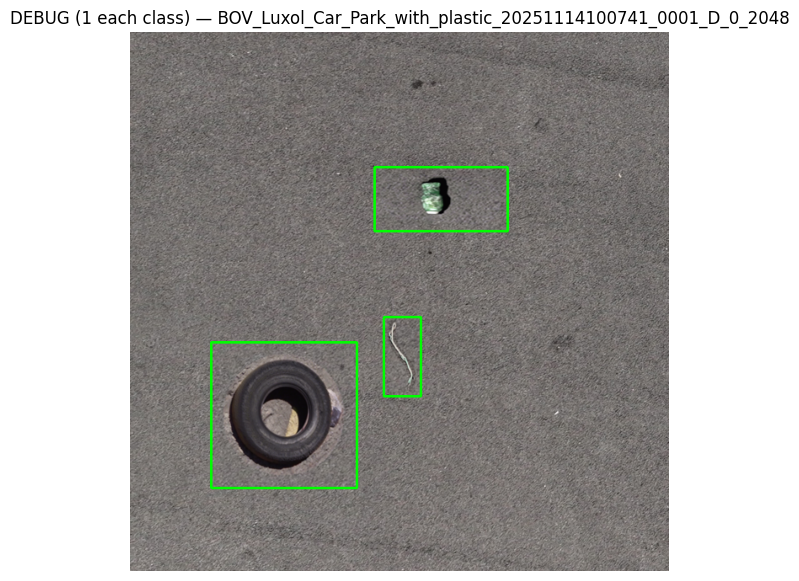

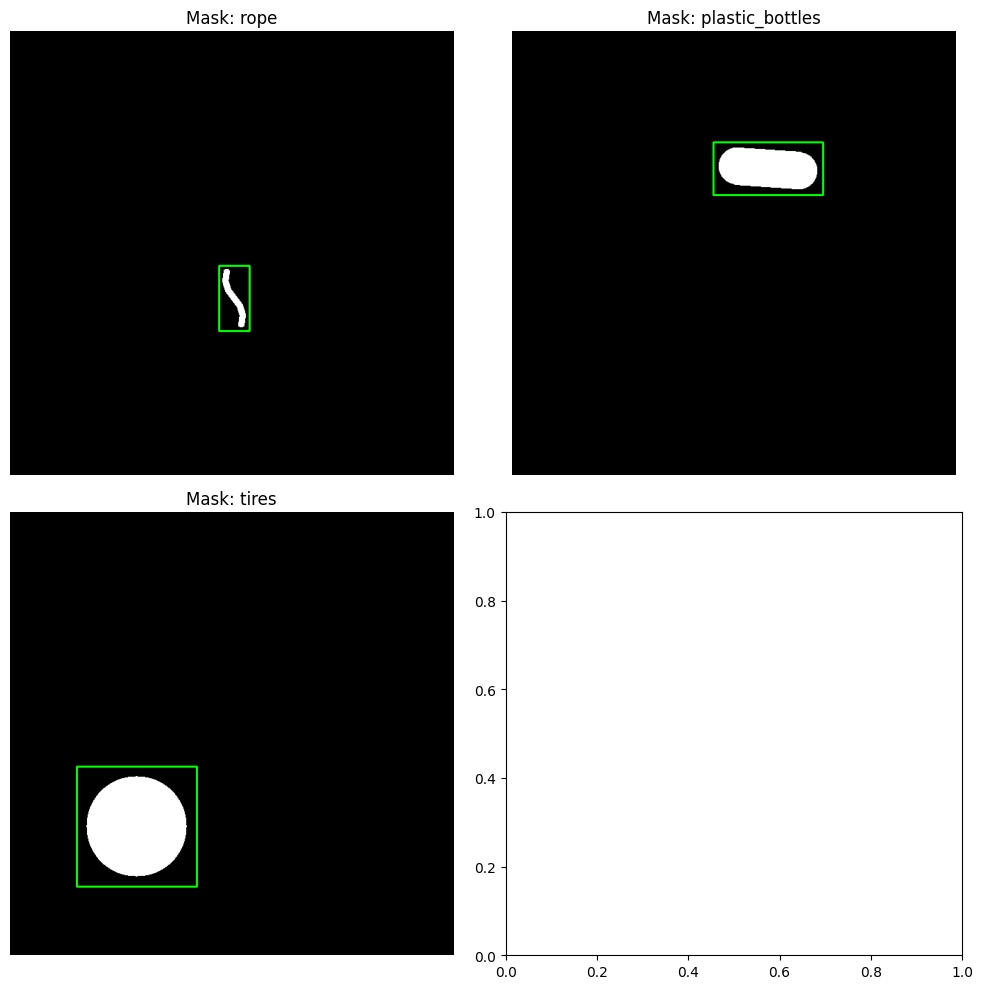

,class,bbox_xyxy,prompt,ref_file,mean_abs_diff
0,rope,"(301, 338, 345, 432)","a partially coiled rope with loose ends, top-d...",/workspace/RD2/IP_ADAPTER_REFERENCES/rope/rope...,7.061
1,plastic_bottles,"(290, 160, 448, 236)","a crushed plastic bottle on sand, top-down dro...",/workspace/RD2/IP_ADAPTER_REFERENCES/plastic_b...,13.585
2,tires,"(96, 368, 269, 541)","a discarded tire lying on sand, top-down drone...",/workspace/RD2/IP_ADAPTER_REFERENCES/tires/tir...,26.075


In [8]:
# -----------------------
# DEBUG — One image, 1 of each class + show masks
# -----------------------
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image

# Pick a single background (change index if you want)
dbg_bg_path = bg_files[0]
dbg_base_name = dbg_bg_path.stem
dbg_img = load_rgb(dbg_bg_path).resize(TARGET_SIZE, resample=Image.BICUBIC)

debug_classes = ["rope", "plastic_bottles", "tires"]

dbg_result = dbg_img.copy()
dbg_bboxes = []
dbg_rows = []
dbg_masks = []  # (cls, mask_full_pil, crop_bbox)

def pick_ref_path(cls: str):
    if cls == "rope":
        return random.choice(rope_ref_files)
    if cls == "plastic_bottles":
        return random.choice(plastic_ref_files)
    return random.choice(tires_ref_files)


def prompt_for(cls: str):
    if cls == "rope":
        return random.choice(ROPE_PROMPTS)
    if cls == "plastic_bottles":
        return random.choice(PLASTIC_PROMPTS)
    if cls == "tires":
        return random.choice(TIRES_PROMPTS)
    raise ValueError(f"Unexpected class: {cls}")


def make_mask_for_class(cls: str):
    spec = MASK_SPECS[cls]
    pad = PADDING_BY_CLASS.get(cls, PADDING)

    if cls == "rope":
        if random.random() < COIL_PROB:
            mask_np, contour = generate_rope_coil_mask((H, W), edge_margin=spec["edge_margin"])
        else:
            mask_np, contour = generate_rope_polyline_mask((H, W), edge_margin=spec["edge_margin"])

    elif cls == "plastic_bottles":
        if random.random() < 0.65:
            mask_np, contour = generate_bottle_mask((H, W), edge_margin=spec["edge_margin"], max_bbox=spec["max_bbox"])
        else:
            mask_np, contour = generate_jug_mask((H, W), edge_margin=spec["edge_margin"], max_bbox=spec["max_bbox"])

    elif cls == "tires":
        mask_np, contour = generate_tire_donut_mask((H, W), edge_margin=spec["edge_margin"], max_bbox=spec["max_bbox"])

    else:
        raise ValueError(f"Unexpected class: {cls}")

    x, y, bw, bh = cv2.boundingRect(contour)
    x1 = max(x - pad, 0); y1 = max(y - pad, 0)
    x2 = min(x + bw + pad, W); y2 = min(y + bh + pad, H)
    return mask_np, (x1, y1, x2, y2)

# Generate 1 per class
for cls in debug_classes:
    # Placement with overlap rejection
    chosen = None
    last_candidate = None
    for _ in range(MAX_PLACEMENT_TRIES):
        mask_np, bbox = make_mask_for_class(cls)
        last_candidate = (mask_np, bbox)
        if max_iou(bbox, dbg_bboxes) <= MAX_IOU:
            chosen = last_candidate
            break
    if chosen is None:
        chosen = last_candidate

    mask_np, (x1, y1, x2, y2) = chosen
    dbg_bboxes.append((x1, y1, x2, y2))

    # Full-size mask image (for display)
    mask_full = Image.fromarray(mask_np).convert("L")
    dbg_masks.append((cls, mask_full, (x1, y1, x2, y2)))

    # Crop current image + mask
    crop_img = dbg_result.crop((x1, y1, x2, y2))
    crop_mask = mask_full.crop((x1, y1, x2, y2))

    crop_img_rs  = crop_img.resize(TARGET_SIZE,  resample=Image.BICUBIC)
    crop_mask_rs = crop_mask.resize(TARGET_SIZE, resample=Image.NEAREST)
    crop_mask_soft = soften_mask(crop_mask_rs, blur=1)

    prompt = prompt_for(cls)

    # Use reference image (and remember which file we used)
    ref_path = pick_ref_path(cls)
    ref_img = load_rgb(ref_path)

    before = crop_img_rs.copy()

    # Try a couple times (same logic)
    best_out = None
    best_diff = -1.0
    for attempt in range(MAX_RETRIES_PER_INSERT + 1):
        gen = build_generator(None)  # keep random
        out_try = pipe(
            prompt=prompt,
            negative_prompt=NEG_PROMPT,
            image=crop_img_rs,
            mask_image=crop_mask_rs,
            ip_adapter_image=ref_img,
            num_inference_steps=NUM_INFERENCE_STEPS,
            guidance_scale=GUIDANCE_SCALE,
        ).images[0]

        if out_try.size != before.size:
            out_try = out_try.resize(before.size, resample=Image.BICUBIC)

        blended = Image.composite(out_try, before, crop_mask_soft)
        d = mean_abs_diff(before, blended)
        if d > best_diff:
            best_diff = d
            best_out = blended
        if d >= MIN_DIFF:
            break

    if best_out is None:
        best_out = before

    # Paste back
    best_out = best_out.resize((x2 - x1, y2 - y1), resample=Image.BICUBIC)
    dbg_result.paste(best_out, (x1, y1))

    dbg_rows.append({
        "class": cls,
        "bbox_xyxy": (x1, y1, x2, y2),
        "prompt": prompt,
        "ref_file": str(ref_path),
        "mean_abs_diff": round(best_diff, 3),
    })

# --- Display: final image with boxes ---
plt.figure(figsize=(7,7))
plt.imshow(draw_bboxes(dbg_result, dbg_bboxes))
plt.title(f"DEBUG (1 each class) — {dbg_base_name}")
plt.axis("off")
plt.show()

# --- Display: masks (full-size + bbox overlay) ---
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for ax, (cls, mask_full, bbox) in zip(axes, dbg_masks):
    m = np.array(mask_full)
    # overlay bbox on mask for clarity
    x1, y1, x2, y2 = bbox
    vis = cv2.cvtColor(m, cv2.COLOR_GRAY2BGR)
    cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
    ax.imshow(vis[..., ::-1])
    ax.set_title(f"Mask: {cls}")
    ax.axis("off")

plt.tight_layout()
plt.show()

# --- Display: details table ---
pd.DataFrame(dbg_rows)


In [9]:

# -----------------------
# Section 4 - Generate images + save YOLO labels + per-object masks + metadata
# -----------------------
last_result = None
last_bboxes = None
last_base_name = None
last_objects = None

def pick_non_rope_class():
    return random.choices(["plastic_bottles", "tires"], weights=[0.7, 0.3], k=1)[0]

def prompt_for(cls: str):
    if cls == "rope":
        return random.choice(ROPE_PROMPTS)
    if cls == "plastic_bottles":
        return random.choice(PLASTIC_PROMPTS)
    return random.choice(TIRES_PROMPTS)

def ref_path_for(cls: str):
    if cls == "rope":
        return random.choice(rope_ref_files)
    if cls == "plastic_bottles":
        return random.choice(plastic_ref_files)
    return random.choice(tires_ref_files)

def ensure_uint8_mask(mask_np):
    return ((mask_np > 0).astype(np.uint8) * 255)

def make_object_mask_name(stem: str, obj_idx: int, cls: str) -> str:
    return f"{stem}__obj{obj_idx:03d}__{cls}.png"

def serialize_bbox(b):
    return [int(b[0]), int(b[1]), int(b[2]), int(b[3])]

all_image_records = []

for img_path in tqdm(bg_files, desc="Background images"):
    base_name = img_path.stem
    base_image = load_rgb(img_path).resize(TARGET_SIZE, resample=Image.BICUBIC)

    for variant_idx in tqdm(range(VARIANTS_PER_BG), leave=False, desc="variants per background"):
        result_img = base_image.copy()

        bboxes = []
        bboxes_keepout = []
        yolo_lines = []
        object_records = []

        total_inserts = random.randint(TOTAL_INSERTS_MIN, TOTAL_INSERTS_MAX)
        n_ropes = min(random.randint(ROPE_INSERTS_MIN, ROPE_INSERTS_MAX), total_inserts)
        n_other = total_inserts - n_ropes
        insert_plan = (["rope"] * n_ropes) + [pick_non_rope_class() for _ in range(n_other)]
        random.shuffle(insert_plan)

        for ins_idx, cls in enumerate(insert_plan):
            chosen = None

            # ---- placement with overlap rejection ----
            for _ in range(MAX_PLACEMENT_TRIES):
                spec = MASK_SPECS[cls]
                pad = PADDING_BY_CLASS.get(cls, PADDING)

                if cls == "rope":
                    if random.random() < COIL_PROB:
                        mask_np, contour = generate_rope_coil_mask((H, W), edge_margin=spec["edge_margin"])
                    else:
                        mask_np, contour = generate_rope_polyline_mask((H, W), edge_margin=spec["edge_margin"])
                elif cls == "plastic_bottles":
                    if random.random() < 0.65:
                        mask_np, contour = generate_bottle_mask((H, W), edge_margin=spec["edge_margin"], max_bbox=spec["max_bbox"])
                    else:
                        mask_np, contour = generate_jug_mask((H, W), edge_margin=spec["edge_margin"], max_bbox=spec["max_bbox"])
                elif cls == "tires":
                    mask_np, contour = generate_tire_donut_mask((H, W), edge_margin=spec["edge_margin"], max_bbox=spec["max_bbox"])
                else:
                    mask_np, contour = generate_debris_polygon_mask((H, W), edge_margin=spec["edge_margin"], min_radius=18, max_radius=55, max_bbox=spec["max_bbox"])

                x, y, bw, bh = cv2.boundingRect(contour)
                x1 = max(x - pad, 0)
                y1 = max(y - pad, 0)
                x2 = min(x + bw + pad, W)
                y2 = min(y + bh + pad, H)

                bbox = (x1, y1, x2, y2)
                keepout = KEEP_OUT_BY_CLASS.get(cls, 14)
                kb = expand_bbox(bbox, keepout, W, H)
                if max_iou_keepout(kb, bboxes_keepout) <= MAX_IOU:
                    chosen = {
                        "mask_np": ensure_uint8_mask(mask_np),
                        "bbox": bbox,
                        "keepout_bbox": kb,
                    }
                    break

            if chosen is None:
                continue

            mask_np = chosen["mask_np"]
            x1, y1, x2, y2 = chosen["bbox"]
            keepout_bbox = chosen["keepout_bbox"]

            mask_img = Image.fromarray(mask_np).convert("L")
            ctx_x1, ctx_y1, ctx_x2, ctx_y2 = compute_context_bbox((x1, y1, x2, y2), W, H)
            crop_img = result_img.crop((ctx_x1, ctx_y1, ctx_x2, ctx_y2))
            crop_mask = mask_img.crop((ctx_x1, ctx_y1, ctx_x2, ctx_y2))

            crop_img_rs, crop_mask_rs, patch_placement = letterbox_to_square(crop_img, crop_mask, target_size=TARGET_SIZE)
            crop_mask_rs = crop_mask_rs.convert("L").point(lambda p: 255 if p > 127 else 0)
            crop_mask_soft = soften_mask(crop_mask_rs, blur=BLUR_BY_CLASS.get(cls, 1))

            base_prompt = prompt_for(cls)
            final_prompt = base_prompt
            ref_path = ref_path_for(cls)
            ref_img = load_rgb(ref_path)

            before = crop_img_rs.copy()
            best_out = None
            best_diff = -1.0
            best_fill_ratio = -1.0
            best_attempt = None

            min_fill = MIN_FILL_RATIO_BY_CLASS.get(cls, 0.0)

            for attempt in range(MAX_RETRIES_PER_INSERT + 1):
                final_prompt = base_prompt
                if cls == "tires" and attempt > 0:
                    final_prompt = base_prompt + ", large, fills the masked area, fully visible"
                if cls == "plastic_bottles" and attempt > 0:
                    final_prompt = base_prompt + ", intact bottle shape, realistic proportions, no ripples, no melting, not heavily crushed"

                seed_val = None
                if SEED is not None:
                    seed_val = SEED + (hash(base_name) % 100000) * 100 + variant_idx * 50 + ins_idx * 3 + attempt
                gen = build_generator(seed_val)

                kwargs = dict(
                    prompt=final_prompt,
                    negative_prompt=NEG_PROMPT,
                    image=crop_img_rs,
                    mask_image=crop_mask_rs,
                    ip_adapter_image=ref_img,
                    num_inference_steps=NUM_INFERENCE_STEPS,
                    guidance_scale=GUIDANCE_SCALE,
                )
                if gen is not None:
                    kwargs["generator"] = gen

                out_try = pipe(**kwargs).images[0]
                if out_try.size != before.size:
                    out_try = out_try.resize(before.size, resample=Image.BICUBIC)

                blended = Image.composite(out_try, before, crop_mask_soft)

                d = masked_mean_abs_diff(before, blended, crop_mask_rs)
                fill_ratio = mask_fill_ratio(before, blended, crop_mask_rs, diff_thr=8)

                if fill_ratio < min_fill:
                    d = min(d, 0.5)

                if d > best_diff:
                    best_diff = float(d)
                    best_fill_ratio = float(fill_ratio)
                    best_out = blended
                    best_attempt = attempt

                if d >= MIN_DIFF and fill_ratio >= min_fill:
                    break

            # Stage-1 heuristic QA: only keep inserts that actually changed the masked area enough
            if best_out is None or best_diff < MIN_DIFF or best_fill_ratio < min_fill:
                continue

            patch_back = unletterbox_from_square(best_out, patch_placement)
            if patch_back.size != (ctx_x2 - ctx_x1, ctx_y2 - ctx_y1):
                patch_back = patch_back.resize((ctx_x2 - ctx_x1, ctx_y2 - ctx_y1), resample=Image.BICUBIC)
            result_img.paste(patch_back, (ctx_x1, ctx_y1))

            bboxes.append((x1, y1, x2, y2))
            bboxes_keepout.append(keepout_bbox)

            class_id = CLASS_MAP[cls]
            yolo_lines.append(bbox_to_yolo_line(class_id, x1, y1, x2, y2, W, H))

            object_records.append({
                "object_index": len(object_records),
                "class_name": cls,
                "class_id": class_id,
                "bbox_xyxy": serialize_bbox((x1, y1, x2, y2)),
                "context_bbox_xyxy": serialize_bbox((ctx_x1, ctx_y1, ctx_x2, ctx_y2)),
                "reference_filename": ref_path.name,
                "reference_path": str(ref_path),
                "generation_prompt": base_prompt,
                "final_prompt": final_prompt,
                "heuristic": {
                    "best_masked_mean_abs_diff": round(best_diff, 4),
                    "best_fill_ratio": round(best_fill_ratio, 4),
                    "min_required_diff": MIN_DIFF,
                    "min_required_fill_ratio": float(min_fill),
                    "accepted_by_stage1": True,
                    "best_attempt": int(best_attempt) if best_attempt is not None else None,
                },
                "mask_area_px": int((mask_np > 0).sum()),
                "mask_relpath": None,  # filled after save
                "qa": {
                    "vlm_verdict": None,
                    "vlm_confidence": None,
                    "vlm_reason": None,
                    "vlm_defect_type": None,
                },
                "_mask_np": mask_np,  # temporary, removed before JSON save
            })

        if not object_records:
            print(f"[SKIP] {base_name}-v{variant_idx+1}: no accepted inserts after stage-1 QA")
            continue

        stem = f"{base_name}-v{variant_idx+1}"
        img_filename = output_image_dir / f"{stem}.png"
        label_filename = output_label_dir / f"{stem}.txt"
        metadata_filename = output_metadata_dir / f"{stem}.json"

        result_img.save(img_filename)
        with open(label_filename, "w", encoding="utf-8") as f:
            f.write("\n".join(yolo_lines))

        for obj in object_records:
            mask_name = make_object_mask_name(stem, obj["object_index"], obj["class_name"])
            mask_path = output_mask_dir / mask_name
            Image.fromarray(obj["_mask_np"]).save(mask_path)
            obj["mask_relpath"] = str(mask_path.relative_to(output_root))
            obj.pop("_mask_np", None)

        image_record = {
            "experiment_name": EXPERIMENT_NAME,
            "image_stem": stem,
            "image_filename": img_filename.name,
            "image_relpath": str(img_filename.relative_to(output_root)),
            "label_relpath": str(label_filename.relative_to(output_root)),
            "metadata_filename": metadata_filename.name,
            "background_filename": img_path.name,
            "background_path": str(img_path),
            "target_size_wh": [W, H],
            "variant_index": int(variant_idx + 1),
            "requested_total_inserts": int(total_inserts),
            "accepted_object_count": int(len(object_records)),
            "objects": object_records,
        }

        with open(metadata_filename, "w", encoding="utf-8") as f:
            json.dump(image_record, f, indent=2)

        all_image_records.append({
            "image_stem": stem,
            "background_filename": img_path.name,
            "variant_index": int(variant_idx + 1),
            "accepted_object_count": int(len(object_records)),
            "image_relpath": str(img_filename.relative_to(output_root)),
            "label_relpath": str(label_filename.relative_to(output_root)),
            "metadata_relpath": str(metadata_filename.relative_to(output_root)),
        })

        last_result = result_img
        last_bboxes = bboxes
        last_base_name = base_name
        last_objects = object_records

        print(f"Saved {img_filename.name} with {len(object_records)} accepted objects.")

        if SHOW_EACH_RESULT:
            plt.figure(figsize=(7, 7))
            plt.imshow(draw_bboxes(result_img, bboxes))
            plt.title(f"{stem} ({len(bboxes)} objs)")
            plt.axis("off")
            plt.show()

if all_image_records:
    manifest_df = pd.DataFrame(all_image_records).sort_values(["background_filename", "variant_index"]).reset_index(drop=True)
    manifest_df.to_csv(manifest_csv_path, index=False)
    with open(manifest_jsonl_path, "w", encoding="utf-8") as f:
        for row in manifest_df.to_dict(orient="records"):
            f.write(json.dumps(row) + "\n")
    print(f"[INFO] Wrote manifest CSV:   {manifest_csv_path}")
    print(f"[INFO] Wrote manifest JSONL: {manifest_jsonl_path}")

print("[DONE] Generation complete.")


Background images:   0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/39 [00:00<?, ?it/s]

  0%|          | 0/39 [00:00<?, ?it/s]

  0%|          | 0/39 [00:00<?, ?it/s]

  0%|          | 0/39 [00:00<?, ?it/s]

...

  0%|          | 0/39 [00:00<?, ?it/s]

  0%|          | 0/39 [00:00<?, ?it/s]

  0%|          | 0/39 [00:00<?, ?it/s]

Background images: 100%|██████████| 30/30 [5:15:12<00:00, 630.40s/it]

Saved St_George_s_Beach_with_plastic_20251114110828_0067_D_0_2676-v5.png with 10 accepted objects.
[INFO] Wrote manifest CSV:   /workspace/RD2/output/PrototypeNine_v1_5/metadata/manifest.csv
[INFO] Wrote manifest JSONL: /workspace/RD2/output/PrototypeNine_v1_5/metadata/manifest.jsonl
[DONE] Generation complete.


In [10]:

# -----------------------
# Section 5 - Manifest summary + quick preview of metadata
# -----------------------
if manifest_csv_path.exists():
    manifest_df = pd.read_csv(manifest_csv_path)
    print(manifest_df.head())
    print()
    print("[INFO] Images saved:", len(manifest_df))
    print("[INFO] Avg objects/image:", round(manifest_df["accepted_object_count"].mean(), 2))
else:
    print("Manifest not found. Run Section 4 first.")

if last_objects:
    print("\n[INFO] Last image object metadata preview:")
    print(json.dumps(last_objects[:2], indent=2))


                                          image_stem  \
0  BOV_Luxol_Car_Park_with_plastic_20251114100741...   
1  BOV_Luxol_Car_Park_with_plastic_20251114100741...   
2  BOV_Luxol_Car_Park_with_plastic_20251114100741...   
3  BOV_Luxol_Car_Park_with_plastic_20251114100741...   
4  BOV_Luxol_Car_Park_with_plastic_20251114100741...   

                                 background_filename  variant_index  \
0  BOV_Luxol_Car_Park_with_plastic_20251114100741...              1   
1  BOV_Luxol_Car_Park_with_plastic_20251114100741...              2   
2  BOV_Luxol_Car_Park_with_plastic_20251114100741...              3   
3  BOV_Luxol_Car_Park_with_plastic_20251114100741...              4   
4  BOV_Luxol_Car_Park_with_plastic_20251114100741...              5   

   accepted_object_count                                      image_relpath  \
0                     13  images/BOV_Luxol_Car_Park_with_plastic_2025111...   
1                      9  images/BOV_Luxol_Car_Park_with_plastic_2025111...   

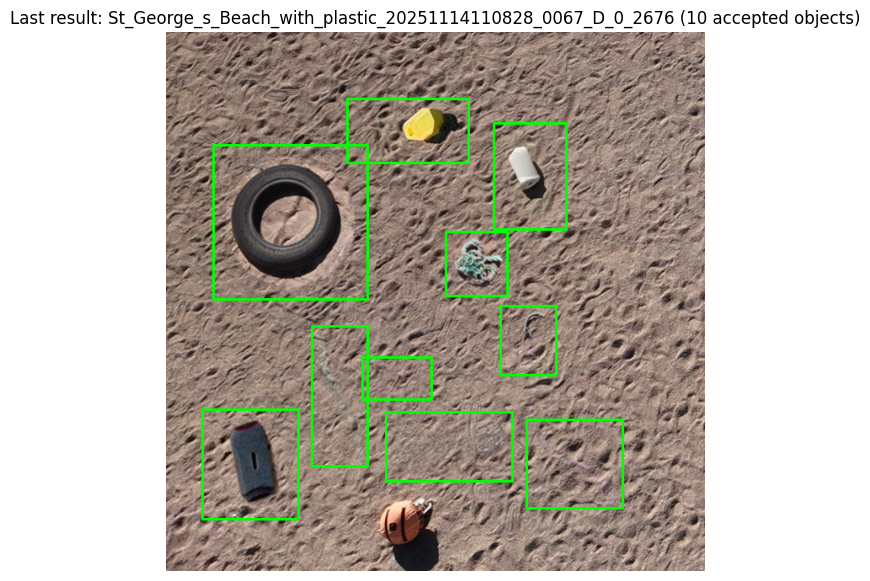

In [11]:

# -----------------------
# Section 6 - Quick visual sanity check (last generated)
# -----------------------
if last_result is not None and last_bboxes is not None:
    plt.figure(figsize=(7, 7))
    plt.imshow(draw_bboxes(last_result, last_bboxes))
    plt.title(f"Last result: {last_base_name} ({len(last_bboxes)} accepted objects)")
    plt.axis("off")
    plt.show()
else:
    print("No last_result found. Run Section 4 first.")
